In [14]:
from Manifold_sculpting import *
from sklearn import datasets, manifold
import matplotlib.pyplot as plt
import umap
from matplotlib.colors import ListedColormap

In [15]:
def plot_data(data, color, title, _3d=False):

    if _3d:
        fig = plt.figure(figsize=(12, 6))
        # Create 3D subplot
        ax1 = fig.add_subplot(121, projection='3d')
        ax1.scatter(data[:,0], data[:,1], data[:,2], c=color, cmap=plt.cm.viridis)
        ax1.set_title('3D Scatter Plot')

        # Create 2D subplot
        ax2 = fig.add_subplot(122)
        ax2.scatter(data[:,0], data[:,1], c=color, cmap=plt.cm.viridis)
        ax2.set_title(title)

    else:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.scatter(data[:,0], data[:,1], c=color, cmap=plt.cm.viridis)
        ax.set_title(title)


    plt.tight_layout()
    plt.show()

In [16]:
def plot_digit(data, title, color=None, c_map='Set3'):
    plt.figure()
    sc = plt.scatter(data[:, 0], data[:, 1], c=color, cmap=c_map, s=30, alpha=0.8, edgecolor='k', linewidth=0.5)

    plt.gca().set_aspect('equal', 'datalim')
    cbar = plt.colorbar(sc, boundaries=np.arange(7)-0.5)
    cbar.set_ticks(np.arange(6))

    plt.title(title)
    plt.show()

In [17]:
n_neighbors = 12
n_components = 2

## Comparing Manifold Sculpting to other dimensionality reduction methods

- **t-SNE**

In [18]:
tsne = manifold.TSNE(n_components=n_components, perplexity=30, n_iter=1000, learning_rate='auto')

- **LLE (different versions)**
The modified version - wich tries to adress the regularization problem of the LLE method, by using multiple weight vectors in each neighborhood - perfors better than the standard one (reasonable since the number of neighbors is higher than the input dimension and MLLE is designed to deal with it)

In [19]:
lle_standard = manifold.LocallyLinearEmbedding(method="standard", n_neighbors=n_neighbors, n_components=n_components)
lle_mod = manifold.LocallyLinearEmbedding(method="modified", n_neighbors=n_neighbors, n_components=n_components)

- **MDS** (metric and non-metric version)

In [20]:
mds = manifold.MDS(n_components=n_components, max_iter=500)
nonmetric_mds = manifold.MDS(n_components=n_components, metric=False, max_iter=500)

- **ISOMAP** with Euclidean distance

In [21]:
isomap = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components, p=2)

- **UMAP**

In [22]:
umap_red = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, n_components=n_components)

## SWISS ROLE

In [23]:
# Generate Swiss roll dataset
n = 1000
noise = 0.0
data, color = datasets.make_swiss_roll(n_samples = n, noise= noise, random_state=9)

### Obtain embeddings

In [24]:
tsne_data = tsne.fit_transform(data)  # 4 seconds 

lle_standard_data = lle_standard.fit_transform(data)
lle_mod_data = lle_mod.fit_transform(data)

mds_data = mds.fit_transform(data)
msd_nonmetric_data = nonmetric_mds.fit_transform(data) # 19 seconds both of them -- rather slow

isomap_data = isomap.fit_transform(data)   # 0.8 seconds both of them - faster and better than MDS

umap_data = umap_red.fit_transform(data) 

### MANIFOLD SCUPLTING with $k=12$ after 430 iterations

In [25]:
manifold_data = np.load("./role_data_checkpoints_1000/embedding_iter_460.npy")

### RESULTS

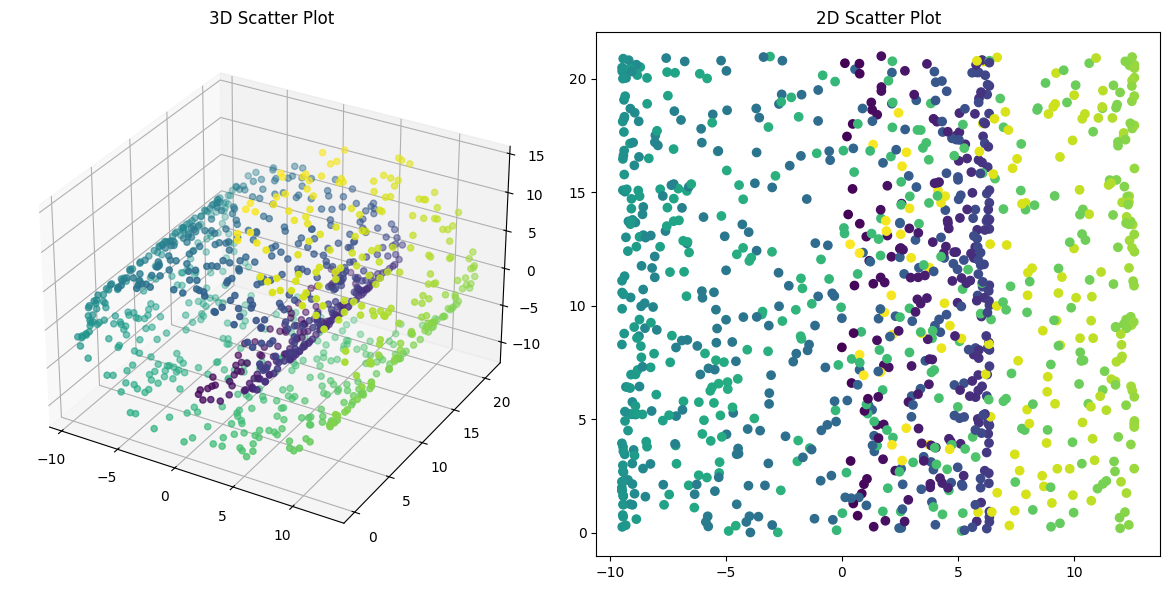

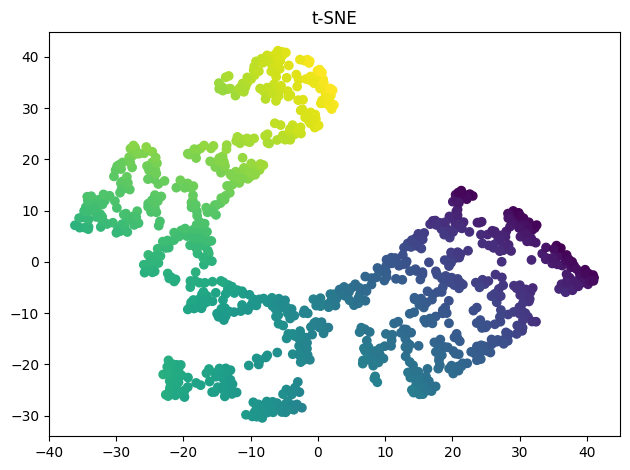

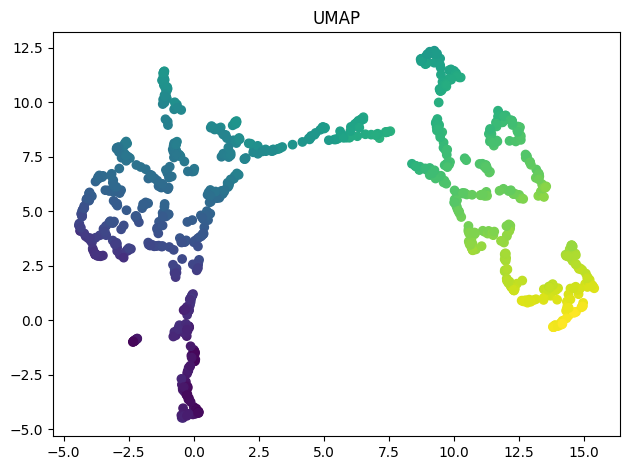

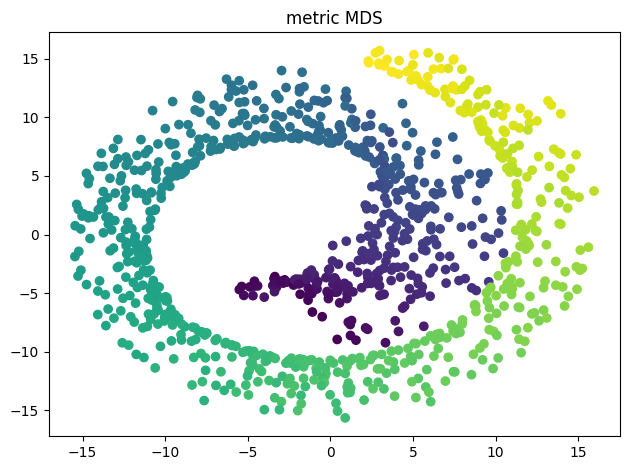

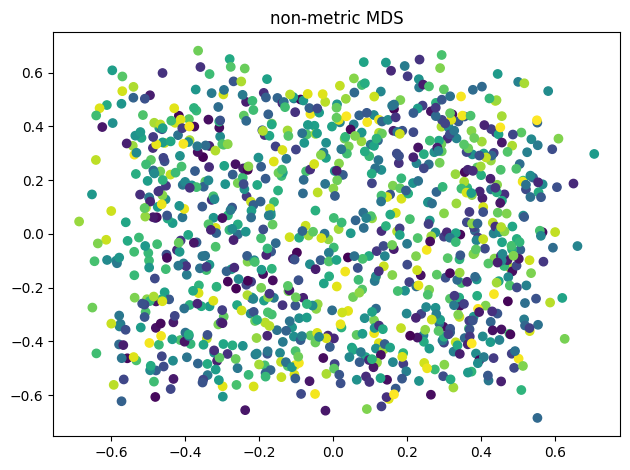

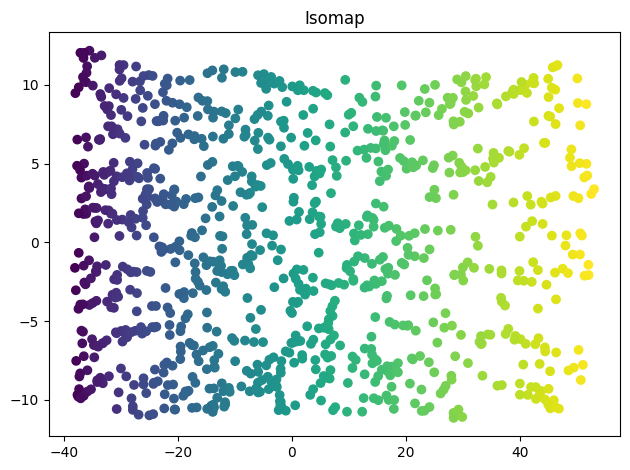

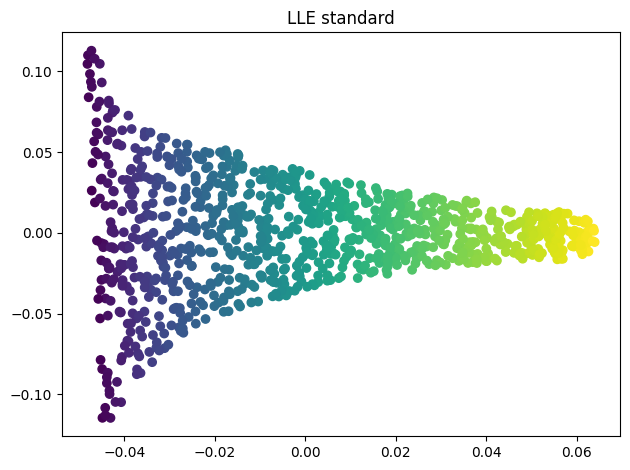

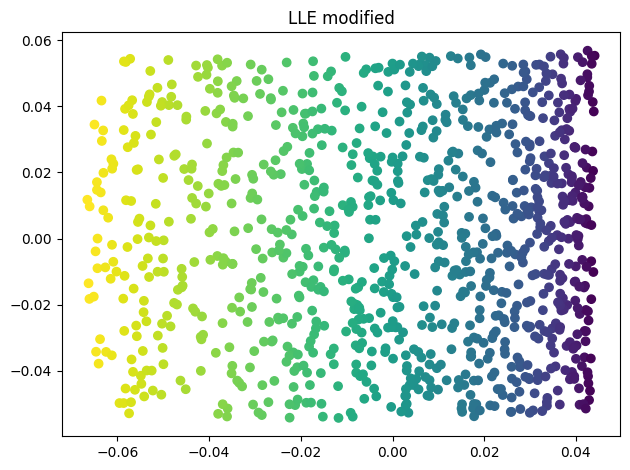

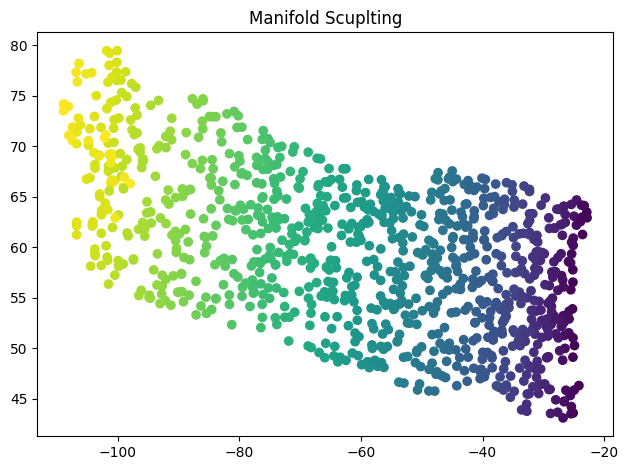

In [26]:
plot_data(data, color, _3d=True, title='2D Scatter Plot')
plot_data(tsne_data, color, title='t-SNE')

plot_data(umap_data, color, title='UMAP')
plot_data(mds_data, color, title='metric MDS')
plot_data(msd_nonmetric_data, color, title='non-metric MDS')
plot_data(isomap_data, color, title='Isomap')

plot_data(lle_standard_data, color, title='LLE standard')
plot_data(lle_mod_data, color, title='LLE modified')

plot_data(manifold_data, color, title='Manifold Scuplting')


## S-CURVE

In [27]:
# GENERATE S-CURVE
n = 1000
noise = 0.0
s_data, color = datasets.make_s_curve(n_samples = n, noise= noise, random_state=9)

### Obtain embedded data 

In [28]:
s_data_tsne = tsne.fit_transform(s_data)

s_data_mds = mds.fit_transform(s_data)
s_data_nonmetric_mds = nonmetric_mds.fit_transform(s_data)

s_data_isomap = isomap.fit_transform(s_data)

s_data_umap = umap_red.fit_transform(s_data)

s_data_lle_standard = lle_standard.fit_transform(s_data)
s_data_lle_mod = lle_mod.fit_transform(s_data)

### MANIFOLD SCULPTING with $k=12$ after 700 iterations

In [29]:
manifold_s_data = np.load("./s_data_checkpoints_1000/embedding_iter_700.npy")

### Results

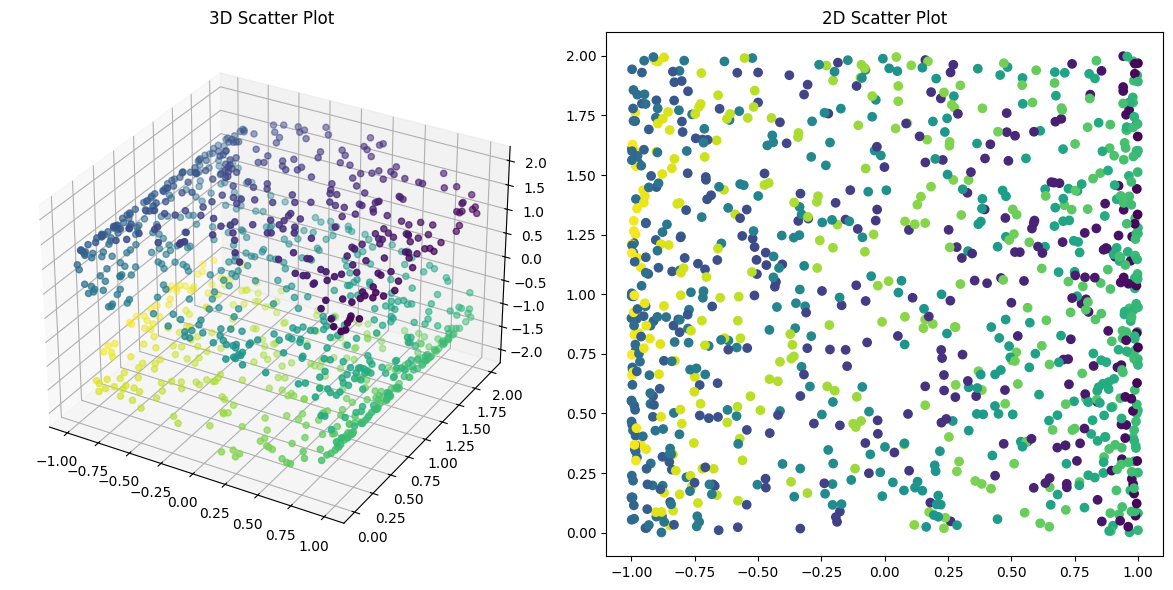

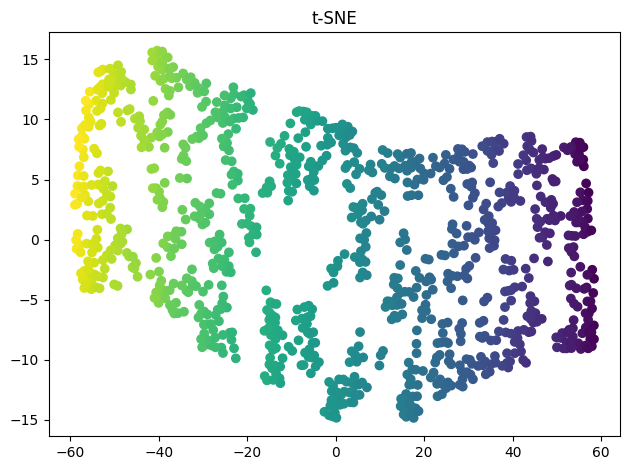

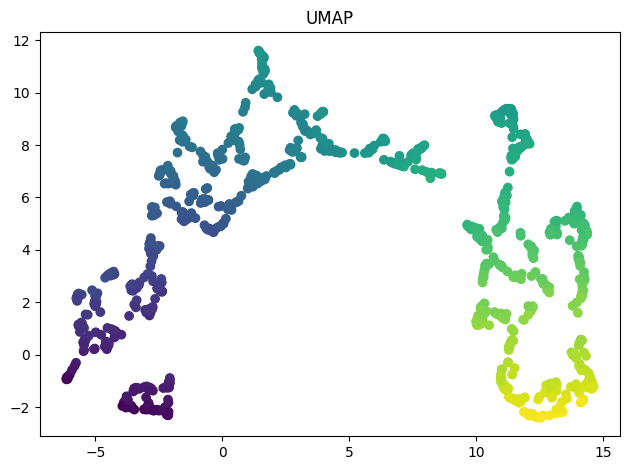

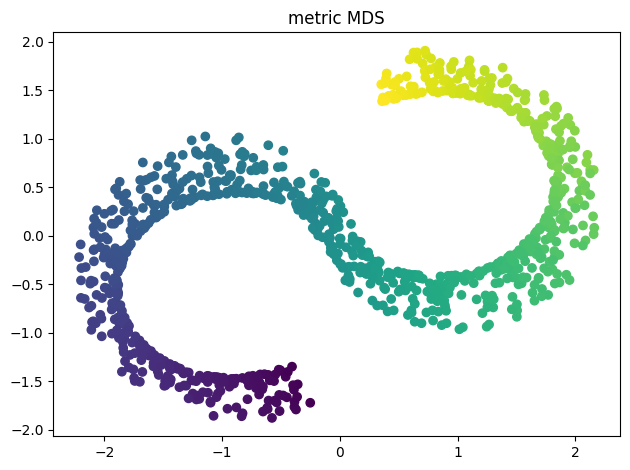

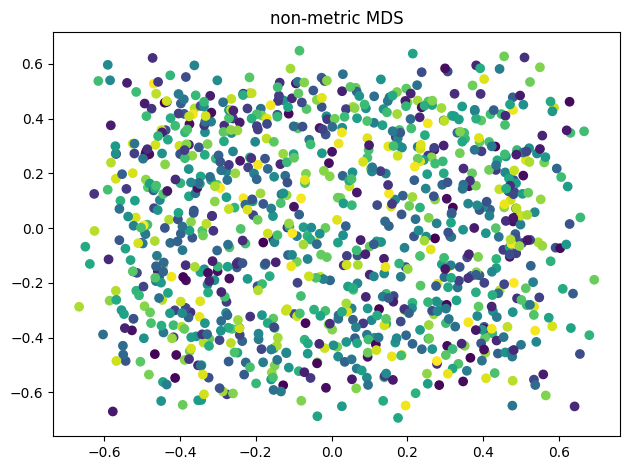

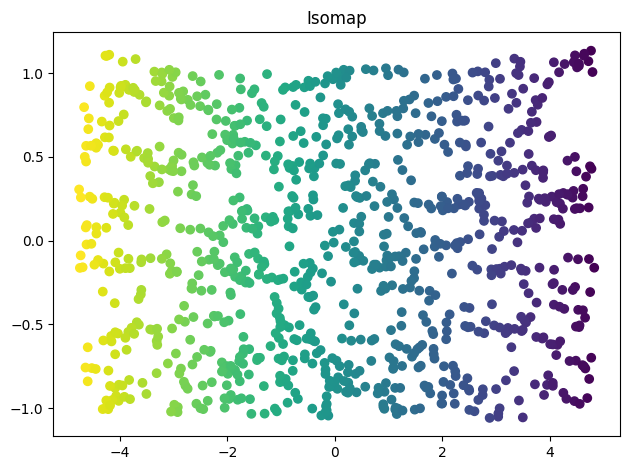

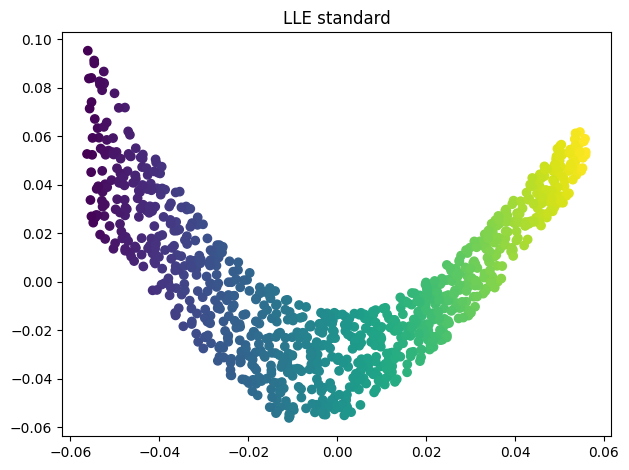

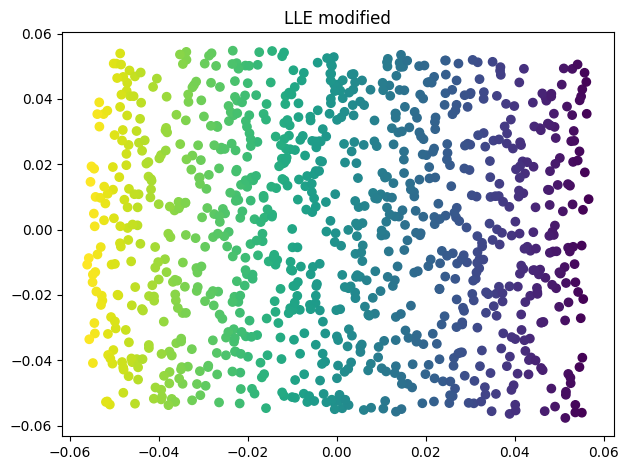

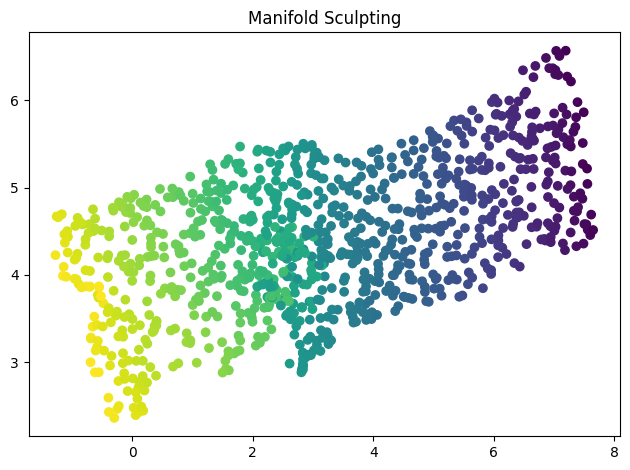

In [31]:
plot_data(s_data, color, _3d=True, title='2D Scatter Plot')
plot_data(s_data_tsne, color, title='t-SNE')


plot_data(s_data_umap, color, title='UMAP')

plot_data(s_data_mds, color, title='metric MDS')
plot_data(s_data_nonmetric_mds, color, title='non-metric MDS')

plot_data(s_data_isomap, color, title='Isomap')

plot_data(s_data_lle_standard, color, title='LLE standard')
plot_data(s_data_lle_mod, color, title='LLE modified')

plot_data(manifold_s_data, color, title='Manifold Sculpting')

## DIGITS

In [5]:
digits = datasets.load_digits(n_class=6)   # from 0 to 5 -- choose 6 classes to have approximately 1000 points for comparability
len(digits.data)

1083

In [42]:
# Create a colormap object from the 'Accent' colormap with 6 colors
cmap = plt.colormaps['Accent']

# Extract the first 4 colors from this colormap
colors = cmap(np.arange(6))

# Create a custom colormap using the first 4 colors
custom_cmap = ListedColormap(colors)

### Obtain embeddings

In [18]:
tsne_digits = tsne.fit_transform(digits.data)

umap_digits = umap_red.fit_transform(digits.data)

isomap_digits = isomap.fit_transform(digits.data)

lle_standard_digits = lle_standard.fit_transform(digits.data)
lle_mod_digits = lle_mod.fit_transform(digits.data)

mds_digits = mds.fit_transform(digits.data)
nonmetric_mds_digits = nonmetric_mds.fit_transform(digits.data)

### Results

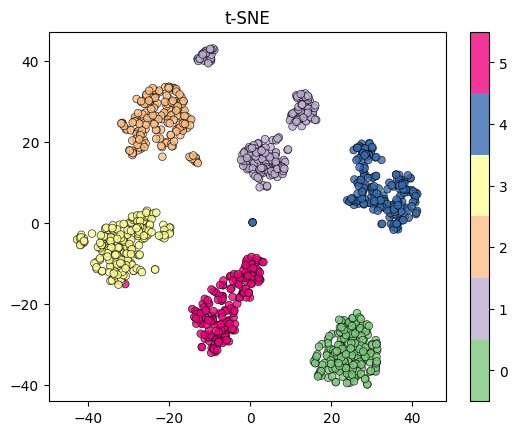

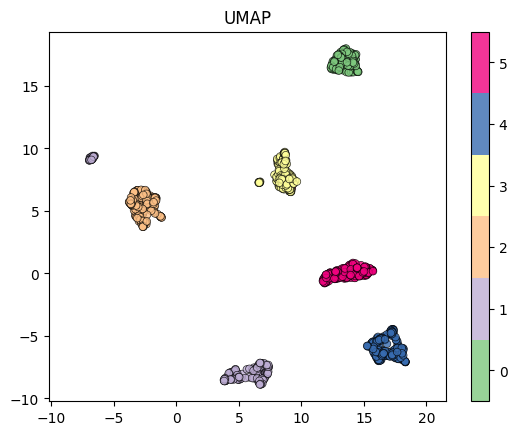

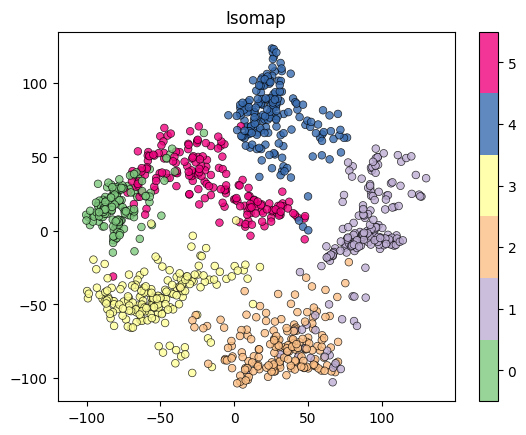

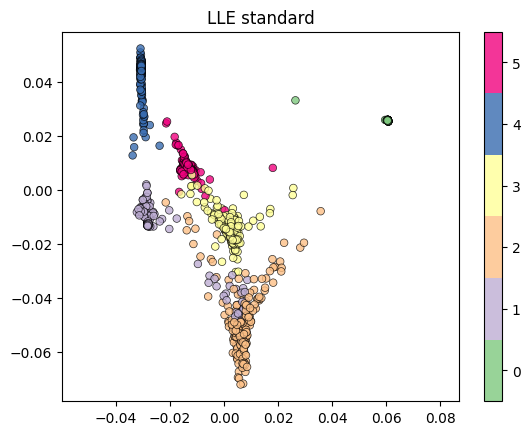

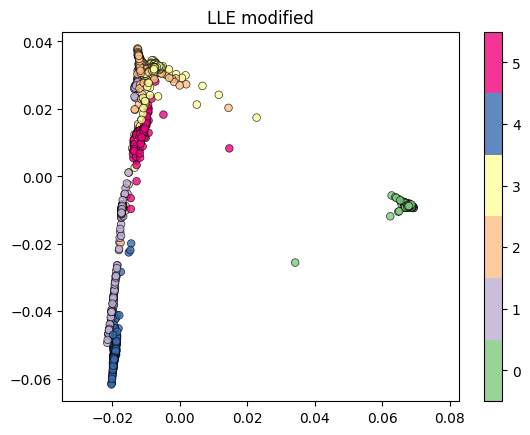

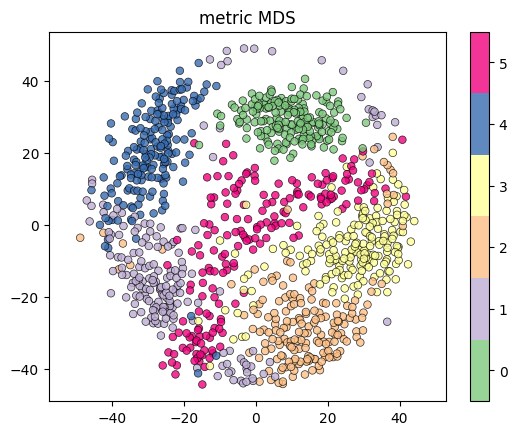

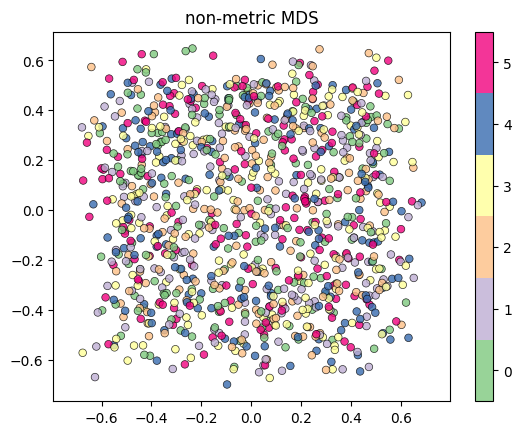

In [45]:
plot_digit(tsne_digits, title='t-SNE', color=digits.target, c_map=custom_cmap)
plot_digit(umap_digits, title='UMAP', color=digits.target, c_map = custom_cmap)
plot_digit(isomap_digits, title='Isomap', color=digits.target, c_map= custom_cmap)
plot_digit(lle_standard_digits, title='LLE standard', color=digits.target, c_map= custom_cmap)
plot_digit(lle_mod_digits, title='LLE modified', color=digits.target, c_map= custom_cmap)
plot_digit(mds_digits, title='metric MDS', color=digits.target, c_map=custom_cmap)
plot_digit(nonmetric_mds_digits, title='non-metric MDS', color=digits.target, c_map=custom_cmap)